# Autoencoder Anomaly Detection

In [63]:
TrainedLabels = [0]
BlacklistLabels = [i for i in range(0, 10) if i not in TrainedLabels]


In [64]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from os.path import join

class AutoEncoder(nn.Module):
	def __init__(self, input_dim=28 * 28, latent_dim=8, dropout=0.10):
		super(AutoEncoder, self).__init__()
		self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Linear(64, latent_dim),
        )
		self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.GELU(),
            nn.Linear(64, 128),
            nn.GELU(),
            nn.Linear(128, 256),
            nn.GELU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )

	def forward(self, x):
		encoded = self.encoder(x)
		decoded = self.decoder(encoded)
		return decoded

class MNISTAnomalyDataset(Dataset):
    def __init__(self, base_dataset, trained_labels):
        self.base_dataset = base_dataset
        self.trained_labels = set(int(label) for label in trained_labels)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        label = int(label)
        image = image.view(-1)
        is_anomaly = 0 if label in self.trained_labels else 1
        return image, torch.tensor(label, dtype=torch.long), torch.tensor(is_anomaly, dtype=torch.long)

## Loading Data

In [65]:
data_root = join('..', 'inputs')

# Train has auto augmentation
train_transform = transforms.Compose([
	transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.IMAGENET,
						interpolation=transforms.InterpolationMode.BILINEAR),
	transforms.ToTensor(),
])
test_transform = transforms.ToTensor()

train_base = datasets.MNIST(root=data_root, train=True, download=True, transform=train_transform)
test_base = datasets.MNIST(root=data_root, train=False, download=True, transform=test_transform)

train_indices = [idx for idx, label in enumerate(train_base.targets) if int(label) in TrainedLabels]
test_indices = list(range(len(test_base)))

train_dataset = Subset(train_base, train_indices)

test_dataset = Subset(test_base, test_indices)

print(f'Training set: {len(train_dataset)} samples')
print(f'Test set: {len(test_dataset)} samples')

Training set: 5923 samples
Test set: 10000 samples


## Prepare Data and Build DataLoaders

In [66]:
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 24
Test batches: 40


## Training

Using device: cpu
Training config: {'latent_dim': 6, 'dropout': 0.05, 'lr': 0.0008, 'weight_decay': 1e-05, 'epochs': 30}
Epoch [1/30], Batch Size: 256, Loss: 0.1699
Epoch [2/30], Batch Size: 256, Loss: 0.0621
Epoch [3/30], Batch Size: 256, Loss: 0.0532
Epoch [4/30], Batch Size: 256, Loss: 0.0511
Epoch [5/30], Batch Size: 256, Loss: 0.0487
Epoch [6/30], Batch Size: 256, Loss: 0.0472
Epoch [7/30], Batch Size: 256, Loss: 0.0450
Epoch [8/30], Batch Size: 256, Loss: 0.0438
Epoch [9/30], Batch Size: 256, Loss: 0.0420
Epoch [10/30], Batch Size: 256, Loss: 0.0397
Epoch [11/30], Batch Size: 256, Loss: 0.0388
Epoch [12/30], Batch Size: 256, Loss: 0.0374
Epoch [13/30], Batch Size: 256, Loss: 0.0358
Epoch [14/30], Batch Size: 256, Loss: 0.0353
Epoch [15/30], Batch Size: 256, Loss: 0.0344
Epoch [16/30], Batch Size: 256, Loss: 0.0339
Epoch [17/30], Batch Size: 256, Loss: 0.0334
Epoch [18/30], Batch Size: 256, Loss: 0.0334
Epoch [19/30], Batch Size: 256, Loss: 0.0328
Epoch [20/30], Batch Size: 256, L

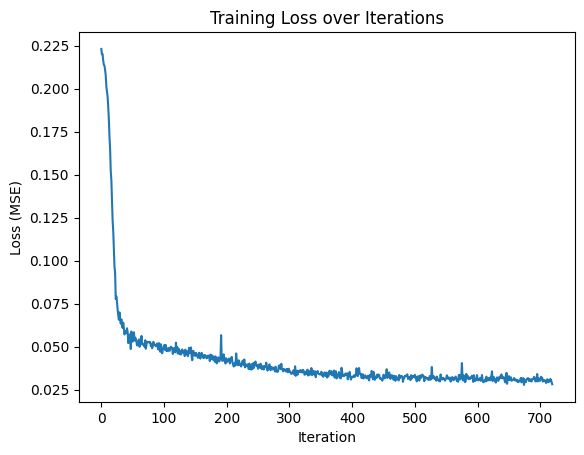

In [67]:
import numpy as np
import matplotlib.pyplot as plt

default_config = {
    'latent_dim': 10,
    'dropout': 0.10,
    'lr': 1e-3,
    'weight_decay': 1e-5,
    'epochs': 30,
}
config = globals().get('TUNED_CONFIG', default_config)

epochs = int(config['epochs'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print('Using CUDA device:', torch.cuda.get_device_name(0))
else:
    print('Using device:', device)

model = AutoEncoder(latent_dim=config['latent_dim'], dropout=config['dropout']).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])

print('Training config:', config)

losses = []
model.train()

for epoch in range(epochs):
    epoch_losses = []
    for batch_images, _ in train_loader:
        batch_images = batch_images.to(device)
        batch_images = batch_images.view(batch_images.size(0), -1)

        output = model(batch_images)
        loss = loss_fn(output, batch_images)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_losses.append(loss.item())

    losses.extend(epoch_losses)
    print('Epoch [{}/{}], Batch Size: {}, Loss: {:.4f}'.format(
        epoch + 1, epochs, batch_size, np.mean(epoch_losses)
    ))

plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Iterations')
plt.show()

## Anomaly Detection

In [68]:
model.eval()
all_inputs = []
all_reconstructed = []
all_labels = []
all_binary = []
all_mse = []

trained_label_set = set(TrainedLabels)

with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        batch_images = batch_images.to(device)
        batch_images = batch_images.view(batch_images.size(0), -1)
        batch_reconstructed = model(batch_images)

        batch_mse = torch.mean((batch_images - batch_reconstructed) ** 2, dim=1)
        batch_binary = torch.tensor(
            [0 if int(label) in trained_label_set else 1 for label in batch_labels],
            dtype=torch.long
        )

        all_inputs.append(batch_images.cpu())
        all_reconstructed.append(batch_reconstructed.cpu())
        all_labels.append(batch_labels.numpy())
        all_binary.append(batch_binary.numpy())
        all_mse.append(batch_mse.cpu().numpy())

x_test = torch.cat(all_inputs, dim=0).numpy()
reconstructed = torch.cat(all_reconstructed, dim=0)
y_test = np.concatenate(all_labels, axis=0)
y_test_binary = np.concatenate(all_binary, axis=0)
mse_values = np.concatenate(all_mse, axis=0)

print('Reconstruction completed.')
print(f'Normal samples (label(s) {TrainedLabels}): {np.sum(y_test_binary == 0)}')
print(f'Anomaly samples (other digits): {np.sum(y_test_binary == 1)}')

Reconstruction completed.
Normal samples (label(s) [0]): 980
Anomaly samples (other digits): 9020


## AUROC Curve

This curve is plotted with respect to the training samples provided by MNIST.

AUROC Score: 0.9568


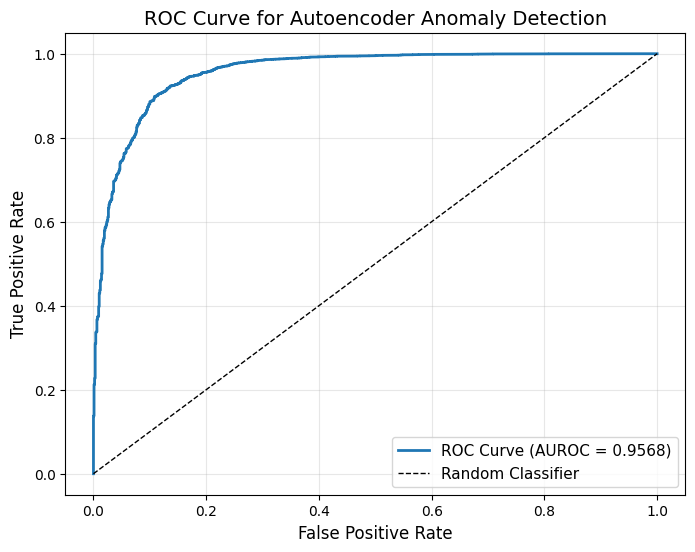

In [69]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, precision_recall_curve
from scipy.optimize import fminbound

# Calculate AUROC
auroc = roc_auc_score(y_test_binary, mse_values)
print(f'AUROC Score: {auroc:.4f}')

# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test_binary, mse_values)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUROC = {auroc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve for Autoencoder Anomaly Detection', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()


=== Optimal Threshold Result ===
Optimal Threshold: 0.032822
F1 Score: 0.9763
Precision: 0.9685
Recall: 0.9843

Confusion Matrix:
TN: 691	 FP: 289
FN: 142	 TP: 8878


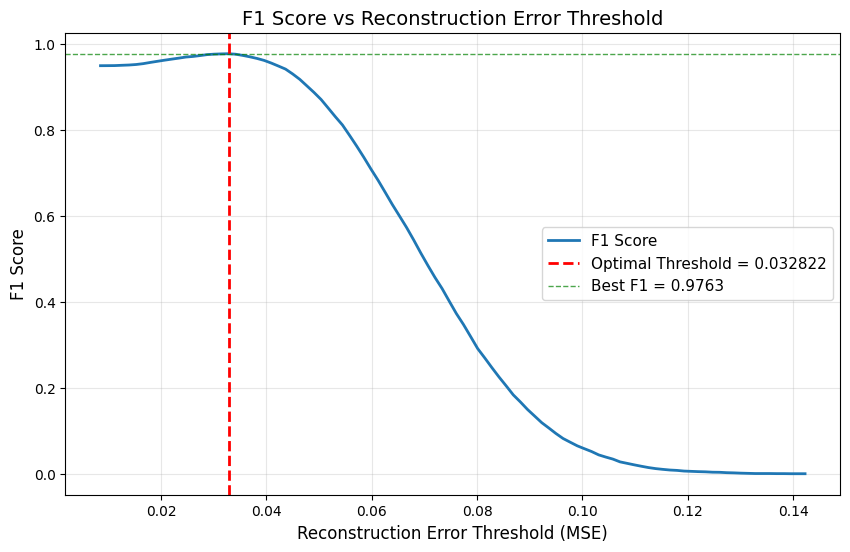

In [70]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Find optimal threshold for F1 score
best_f1 = 0
best_threshold = 0
f1_scores = []
thresholds_f1 = np.linspace(mse_values.min(), mse_values.max(), 100)

for threshold in thresholds_f1:
    y_pred = (mse_values >= threshold).astype(int)
    f1 = f1_score(y_test_binary, y_pred, zero_division=0)
    f1_scores.append(f1)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

y_pred_optimal = (mse_values >= best_threshold).astype(int)
precision = precision_score(y_test_binary, y_pred_optimal, zero_division=0)
recall = recall_score(y_test_binary, y_pred_optimal, zero_division=0)
cm = confusion_matrix(y_test_binary, y_pred_optimal)

print(f'\n=== Optimal Threshold Result ===')
print(f'Optimal Threshold: {best_threshold:.6f}')
print(f'F1 Score: {best_f1:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'\nConfusion Matrix:')
print(f'TN: {cm[0, 0]}\t FP: {cm[0, 1]}')
print(f'FN: {cm[1, 0]}\t TP: {cm[1, 1]}')

plt.figure(figsize=(10, 6))
plt.plot(thresholds_f1, f1_scores, linewidth=2, label='F1 Score')
plt.axvline(best_threshold, color='r', linestyle='--', linewidth=2, label=f'Optimal Threshold = {best_threshold:.6f}')
plt.axhline(best_f1, color='g', linestyle='--', linewidth=1, alpha=0.7, label=f'Best F1 = {best_f1:.4f}')
plt.xlabel('Reconstruction Error Threshold (MSE)', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('F1 Score vs Reconstruction Error Threshold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Reconstruction Test

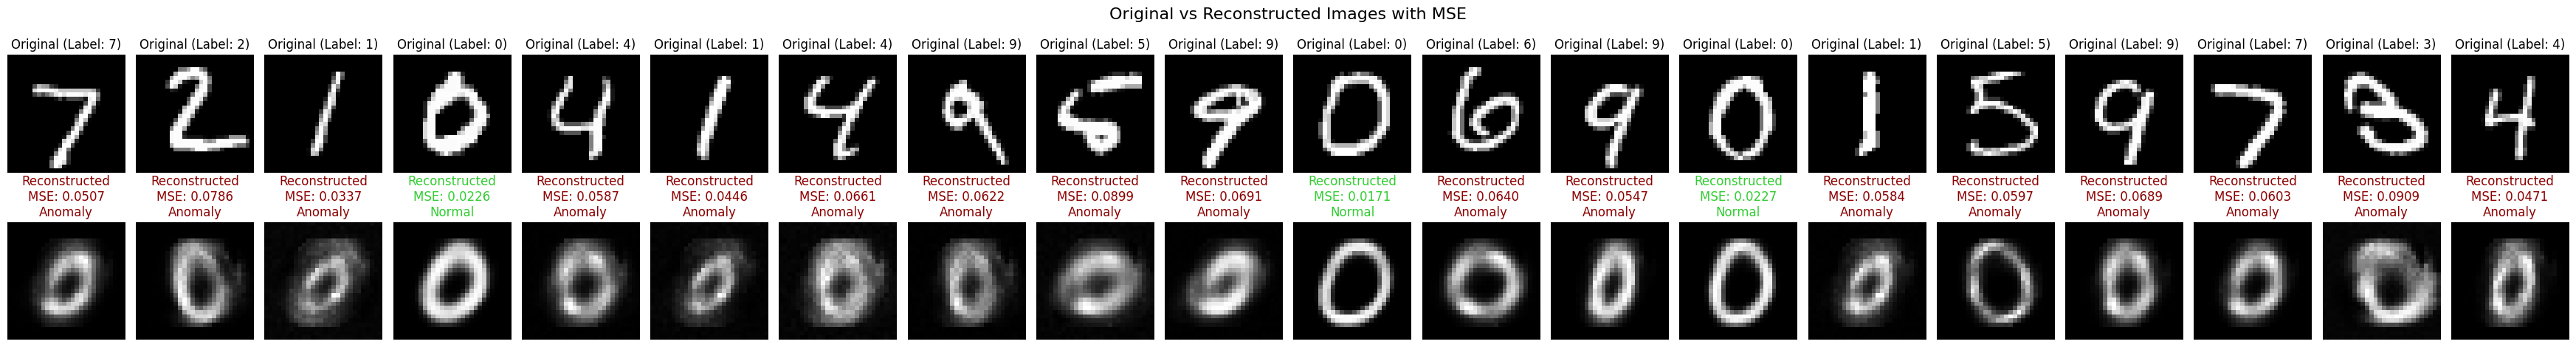

In [71]:
# show first 20 test samples with their reconstruction and MSE
num_samples_to_show = 20
plt.figure(figsize=(35, 5))
for i in range(num_samples_to_show):
	original_image = x_test[i].reshape(28, 28)
	reconstructed_image = reconstructed[i].cpu().numpy().reshape(28, 28)
	mse_value = mse_values[i]

	
	plt.subplot(2, num_samples_to_show, i + 1)
	plt.imshow(original_image, cmap='gray')
	plt.title(f'Original (Label: {y_test[i]})')
	plt.axis('off')
	
	plt.subplot(2, num_samples_to_show, num_samples_to_show + i + 1)
	plt.imshow(reconstructed_image, cmap='gray')
	plt.title(f'Reconstructed\nMSE: {mse_value:.4f}')
	plt.axis('off')
	# show if it's anomaly or not with the f1 optimal threshold
	# anomaly is red text, normal is green text
	is_anomaly = mse_value >= best_threshold
	if is_anomaly:
		plt.gca().set_title(f'Reconstructed\nMSE: {mse_value:.4f}\nAnomaly', color='#8B0000')
	else:
		plt.gca().set_title(f'Reconstructed\nMSE: {mse_value:.4f}\nNormal', color='limegreen')

plt.suptitle('Original vs Reconstructed Images with MSE', fontsize=16)
plt.tight_layout()
plt.show()
